# Real-data backtest — Yahoo Finance

Обновлённая версия исходного ноутбука: вместо синтетических цен используются реальные исторические данные Yahoo Finance. Код также избегает входа по будущей цене: сигнал формируется после текущего бара, вход — на следующем Open.


DATA CHECK
AAPL: 2015-01-02 -> 2026-09-11, 2,940 bars
MSFT: 2015-01-02 -> 2026-09-11, 2,940 bars
AAPL dividend events: 47

1. Dividend gap — AAPL
trades                  : 47
win_rate                : 0.447
avg_R                   : 0.207
profit_factor           : 1.254
total_return_pct        : 7.1
max_drawdown_pct        : -8.71
sharpe_annualized       : 1.681
final_capital           : 107097.54

Last 5 trades:
entry_date  exit_date direction  entry_price  exit_price   shares      pnl  r_multiple exit_reason          tag
2025-08-12 2025-08-25      long       228.01    227.0464 231.3339  -275.54      -0.211   time_exit dividend_gap
2025-11-11 2025-11-24      long       269.81    275.7821 194.9842  1111.27       1.107   time_exit dividend_gap
2026-02-10 2026-02-12      long       274.89    269.2575 193.4021 -1141.96      -1.024   stop_loss dividend_gap
2026-05-12 2026-05-22      long       292.56    309.9585 179.7694  3073.57       2.974 take_profit dividend_gap
2026-08-11 2026-08-12 

,trades,win_rate,avg_R,profit_factor,total_return_pct,max_drawdown_pct,sharpe_annualized,final_capital
Dividend gap,47.0,0.447,0.207,1.254,7.10,-8.71,1.681,107097.54
Pairs,48.0,0.312,-0.112,0.713,-10.13,-12.62,-2.402,89873.95
Support,88.0,0.352,0.077,1.056,3.01,-19.51,0.456,103005.89
Range volatility,56.0,0.589,-0.073,0.637,-7.67,-10.81,-3.073,92329.01



WALK-FORWARD — SUPPORT STRATEGY


,fold,test_start,test_end,trades,return_pct,win_rate,profit_factor,max_dd_pct
0,1,2016-08-19,2017-05-03,1,-1.04,0.000,0.000,-1.04
1,2,2018-12-20,2019-09-04,3,-3.25,0.000,0.000,-3.25
2,3,2021-04-23,2022-01-03,2,-0.19,0.500,0.826,-1.08
3,4,2023-08-24,2024-05-07,9,7.23,0.444,2.645,-2.85
4,5,2025-12-29,2026-09-11,7,9.76,0.714,5.462,-2.19



MONTE CARLO — REAL HISTORICAL TRADES

Dividend gap
  P(max DD >= 20%): 0.015
  P(max DD >= 50%): 0.0
  median_final_equity: 121614.02
  p5_final_equity: 96477.96
  p95_final_equity: 154401.45

Pairs
  P(max DD >= 20%): 0.467
  P(max DD >= 50%): 0.0
  median_final_equity: 87862.61
  p5_final_equity: 71282.6
  p95_final_equity: 111568.27

Support
  P(max DD >= 20%): 0.156
  P(max DD >= 50%): 0.0
  median_final_equity: 106180.41
  p5_final_equity: 81838.56
  p95_final_equity: 139430.49

Range volatility
  P(max DD >= 20%): 0.041
  P(max DD >= 50%): 0.0
  median_final_equity: 92767.3
  p5_final_equity: 82356.19
  p95_final_equity: 103853.87


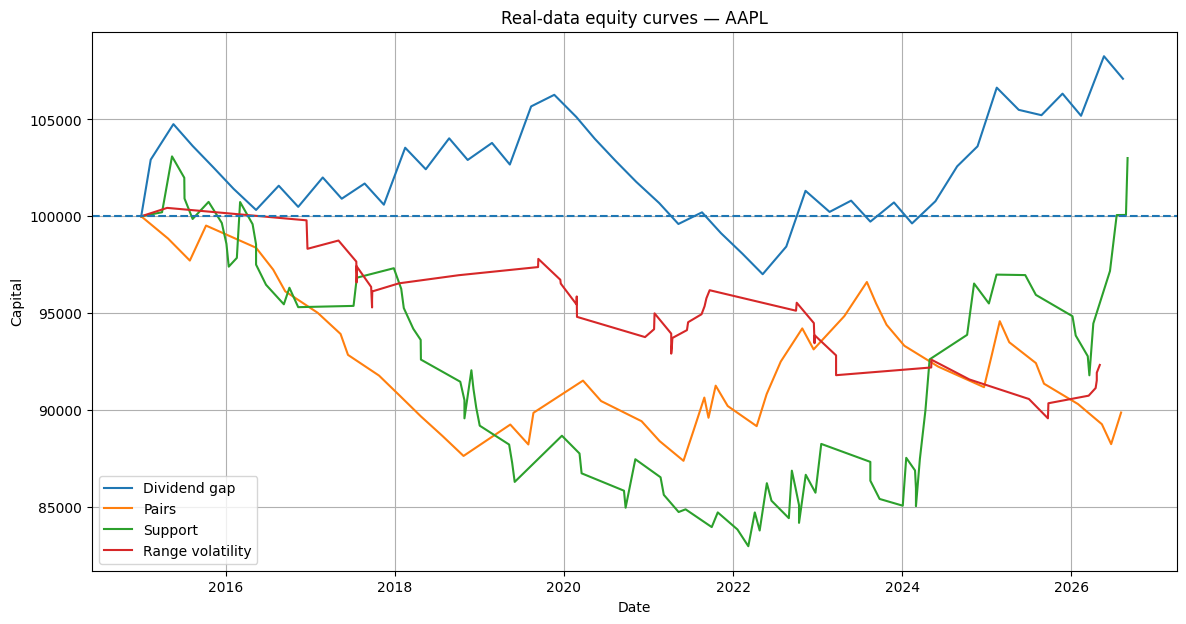


HOW TO INTERPRET THE RESULT

Do NOT select a strategy just because total_return_pct is positive.

For a serious candidate, look for:
1. Enough trades (ideally hundreds over a long history, depending on timeframe).
2. Positive out-of-sample / walk-forward performance.
3. Profit factor > 1 after commission + slippage.
4. Stable results across different periods.
5. Acceptable max drawdown.
6. No single tiny period producing most of the profit.
7. Monte-Carlo robustness.
8. Parameters chosen on TRAIN only, never optimized on TEST.
9. Paper trading before any real capital.
10. For pairs trading, use a true two-leg P&L model before treating it as tradable.

The current code uses real historical Yahoo Finance data, but it is still
a backtest. It does NOT prove that any strategy has a future edge.



In [1]:

# ============================================================
# REAL-DATA BACKTEST — Yahoo Finance
# ============================================================
# Google Colab:
# 1) Run this cell.
# 2) Change TICKER_A / TICKER_B if needed.
# 3) The code downloads REAL historical OHLCV + dividend data
#    from Yahoo Finance and runs the 4 strategies.
#
# IMPORTANT:
# This is research/paper-backtesting code, not a guarantee of
# future profitability. Yahoo Finance data can contain revisions,
# corporate-action adjustments and survivorship limitations.
# ============================================================

!pip -q install yfinance

from dataclasses import dataclass
from typing import Optional, List
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
TICKER_A = "AAPL"       # change to your asset
TICKER_B = "MSFT"       # pair-trading second asset

START = "2015-01-01"
END = None              # None = up to the latest available data

INITIAL_CAPITAL = 100_000
RISK_PCT = 0.01         # 1% per trade for the first real-data test
MAX_LEVERAGE = 2.0
COMMISSION_PCT = 0.0005
SLIPPAGE_PCT = 0.0005

# -----------------------------
# DATA
# -----------------------------
def load_yahoo(ticker, start=START, end=END):
    print(f"Downloading {ticker}...")
    df = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
        actions=False,
    )

    if df.empty:
        raise ValueError(f"No data returned for {ticker}")

    # yfinance may return MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df.columns = [str(c).lower().replace(" ", "_") for c in df.columns]

    required = ["open", "high", "low", "close"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{ticker}: missing columns {missing}")

    df = df[required].copy()
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.dropna()
    df.index = pd.to_datetime(df.index).tz_localize(None)
    df = df[~df.index.duplicated()].sort_index()

    return df


def load_dividends(ticker, start=START, end=END):
    t = yf.Ticker(ticker)
    div = t.dividends

    if div is None or len(div) == 0:
        return pd.DataFrame(columns=["ex_date", "dividend_amount"])

    div = pd.Series(div).copy()
    div.index = pd.to_datetime(div.index).tz_localize(None)

    start_ts = pd.Timestamp(start)
    if end is not None:
        end_ts = pd.Timestamp(end)
        div = div[(div.index >= start_ts) & (div.index <= end_ts)]
    else:
        div = div[div.index >= start_ts]

    return pd.DataFrame({
        "ex_date": div.index,
        "dividend_amount": div.values,
    })


stock_a = load_yahoo(TICKER_A)
stock_b = load_yahoo(TICKER_B)
dividends_a = load_dividends(TICKER_A)

print("\nDATA CHECK")
print(f"{TICKER_A}: {stock_a.index.min().date()} -> {stock_a.index.max().date()}, {len(stock_a):,} bars")
print(f"{TICKER_B}: {stock_b.index.min().date()} -> {stock_b.index.max().date()}, {len(stock_b):,} bars")
print(f"{TICKER_A} dividend events: {len(dividends_a)}")

# -----------------------------
# RISK
# -----------------------------
@dataclass
class RiskConfig:
    capital: float
    risk_pct: float = RISK_PCT
    max_leverage: float = MAX_LEVERAGE
    reward_risk_ratio: float = 3.0


def position_size(entry_price, stop_price, cfg):
    if entry_price <= 0 or stop_price <= 0:
        raise ValueError("Prices must be positive")
    if entry_price == stop_price:
        raise ValueError("entry and stop cannot be equal")

    risk_amount = cfg.capital * cfg.risk_pct
    per_share_risk = abs(entry_price - stop_price)

    shares = risk_amount / per_share_risk
    position_value = shares * entry_price
    leverage_used = position_value / cfg.capital

    if leverage_used > cfg.max_leverage:
        position_value = cfg.capital * cfg.max_leverage
        shares = position_value / entry_price
        leverage_used = cfg.max_leverage
        risk_amount = shares * per_share_risk

    return {
        "shares": shares,
        "position_value": position_value,
        "risk_amount_1R": risk_amount,
        "leverage_used": leverage_used,
    }

# -----------------------------
# SIGNAL / TRADE
# -----------------------------
@dataclass
class Signal:
    date: pd.Timestamp
    direction: str
    entry: float
    stop: float
    target: Optional[float] = None
    max_hold_days: int = 10
    tag: str = ""


@dataclass
class Trade:
    entry_date: pd.Timestamp
    exit_date: pd.Timestamp
    direction: str
    entry_price: float
    exit_price: float
    shares: float
    pnl: float
    r_multiple: float
    exit_reason: str
    tag: str = ""


class Backtester:
    def __init__(
        self,
        price_df,
        initial_capital=INITIAL_CAPITAL,
        risk_pct=RISK_PCT,
        reward_risk_ratio=3.0,
        max_leverage=MAX_LEVERAGE,
        commission_pct=COMMISSION_PCT,
        slippage_pct=SLIPPAGE_PCT,
    ):
        self.df = price_df
        self.initial_capital = initial_capital
        self.capital = initial_capital
        self.risk_pct = risk_pct
        self.reward_risk_ratio = reward_risk_ratio
        self.max_leverage = max_leverage
        self.commission_pct = commission_pct
        self.slippage_pct = slippage_pct
        self.trades = []
        self.equity_curve = []

    def run(self, signals):
        self.capital = self.initial_capital
        self.trades = []
        self.equity_curve = [(self.df.index[0], self.capital)]

        # chronological + remove duplicate dates
        signals = sorted(signals, key=lambda x: x.date)
        used_dates = set()

        for sig in signals:
            # one-position-at-a-time approximation
            if sig.date in used_dates:
                continue

            cfg = RiskConfig(
                capital=self.capital,
                risk_pct=self.risk_pct,
                max_leverage=self.max_leverage,
                reward_risk_ratio=self.reward_risk_ratio,
            )

            sizing = position_size(sig.entry, sig.stop, cfg)
            shares = sizing["shares"]

            target = sig.target
            if target is None:
                distance = abs(sig.entry - sig.stop)
                target = (
                    sig.entry + self.reward_risk_ratio * distance
                    if sig.direction == "long"
                    else sig.entry - self.reward_risk_ratio * distance
                )

            trade = self._simulate_single_trade(sig, shares, target)

            if trade is None:
                continue

            self.capital += trade.pnl
            self.trades.append(trade)
            self.equity_curve.append((trade.exit_date, self.capital))
            used_dates.add(sig.date)

        return self.results()

    def _simulate_single_trade(self, sig, shares, target):
        # IMPORTANT:
        # Signal is generated using information available at sig.date.
        # The entry price supplied to Signal is the NEXT trading day's OPEN
        # for strategies that explicitly generate it that way.
        future = self.df[self.df.index >= sig.date].head(sig.max_hold_days)

        if future.empty:
            return None

        entry_price = sig.entry

        exit_price = None
        exit_date = None
        exit_reason = "time_exit"

        for date, row in future.iterrows():
            if sig.direction == "long":
                if row["low"] <= sig.stop:
                    exit_price = sig.stop
                    exit_date = date
                    exit_reason = "stop_loss"
                    break
                if row["high"] >= target:
                    exit_price = target
                    exit_date = date
                    exit_reason = "take_profit"
                    break
            else:
                if row["high"] >= sig.stop:
                    exit_price = sig.stop
                    exit_date = date
                    exit_reason = "stop_loss"
                    break
                if row["low"] <= target:
                    exit_price = target
                    exit_date = date
                    exit_reason = "take_profit"
                    break

        if exit_price is None:
            exit_price = float(future.iloc[-1]["close"])
            exit_date = future.index[-1]

        # Slippage on exit
        exit_price_adj = (
            exit_price * (1 - self.slippage_pct)
            if sig.direction == "long"
            else exit_price * (1 + self.slippage_pct)
        )

        gross = (
            (exit_price_adj - entry_price) * shares
            if sig.direction == "long"
            else (entry_price - exit_price_adj) * shares
        )

        commission = (
            (entry_price + exit_price_adj) * shares * self.commission_pct
        )

        pnl = gross - commission

        risk_per_share = abs(sig.entry - sig.stop)
        r_multiple = (
            ((exit_price_adj - entry_price) / risk_per_share)
            if sig.direction == "long"
            else ((entry_price - exit_price_adj) / risk_per_share)
        )

        return Trade(
            entry_date=sig.date,
            exit_date=exit_date,
            direction=sig.direction,
            entry_price=round(entry_price, 4),
            exit_price=round(exit_price_adj, 4),
            shares=round(shares, 4),
            pnl=round(pnl, 2),
            r_multiple=round(r_multiple, 3),
            exit_reason=exit_reason,
            tag=sig.tag,
        )

    def results(self):
        if not self.trades:
            return pd.DataFrame()
        return pd.DataFrame([t.__dict__ for t in self.trades])

    def metrics(self):
        df = self.results()
        if df.empty:
            return {"trades": 0}

        wins = df[df.pnl > 0]
        losses = df[df.pnl <= 0]

        equity = pd.Series(
            [e[1] for e in self.equity_curve],
            index=[e[0] for e in self.equity_curve],
        )

        running_max = equity.cummax()
        drawdown = equity / running_max - 1
        max_dd = drawdown.min()

        # More meaningful annualized Sharpe from irregular trade equity:
        # calculate returns between consecutive completed trades.
        returns = equity.pct_change().dropna()
        sharpe = (
            returns.mean() / returns.std() * np.sqrt(252)
            if len(returns) > 1 and returns.std() > 0
            else 0.0
        )

        gross_win = wins.pnl.sum()
        gross_loss = abs(losses.pnl.sum())

        return {
            "trades": int(len(df)),
            "win_rate": round(float((df.pnl > 0).mean()), 3),
            "avg_R": round(float(df.r_multiple.mean()), 3),
            "profit_factor": round(float(gross_win / gross_loss), 3)
                if gross_loss > 0 else float("inf"),
            "total_return_pct": round(
                float((self.capital / self.initial_capital - 1) * 100), 2
            ),
            "max_drawdown_pct": round(float(max_dd * 100), 2),
            "sharpe_annualized": round(float(sharpe), 3),
            "final_capital": round(float(self.capital), 2),
        }

# -----------------------------
# HELPERS
# -----------------------------
def next_open(df, date):
    pos = df.index.searchsorted(pd.Timestamp(date), side="right")
    if pos >= len(df):
        return None, None
    return df.index[pos], float(df["open"].iloc[pos])


def print_report(name, bt):
    print(f"\n{'='*70}")
    print(name)
    print("="*70)

    m = bt.metrics()
    for k, v in m.items():
        print(f"{k:24s}: {v}")

    if m.get("trades", 0) > 0:
        trades = bt.results()
        print("\nLast 5 trades:")
        print(trades.tail(5).to_string(index=False))


# -----------------------------
# STRATEGY 1: DIVIDEND GAP
# -----------------------------
def dividend_gap_strategy(df, dividend_events, stop_pct=0.02, max_hold_days=10):
    signals = []

    for _, row in dividend_events.iterrows():
        ex_date = pd.Timestamp(row["ex_date"])

        if ex_date not in df.index:
            continue

        # NO LOOK-AHEAD:
        # signal is known on ex-date close; actual entry is next trading day's open.
        entry_date, entry = next_open(df, ex_date)
        if entry is None:
            continue

        stop = entry * (1 - stop_pct)

        signals.append(
            Signal(
                date=entry_date,
                direction="long",
                entry=entry,
                stop=stop,
                target=None,
                max_hold_days=max_hold_days,
                tag="dividend_gap",
            )
        )

    return signals


# -----------------------------
# STRATEGY 2: PAIRS (A leg)
# -----------------------------
def pairs_trading_strategy(
    df_a,
    df_b,
    lookback=60,
    entry_z=2.0,
    exit_z=0.5,
    max_hold_days=20,
):
    common = df_a.index.intersection(df_b.index)
    a = df_a.loc[common, "close"]
    b = df_b.loc[common, "close"]

    spread = np.log(a) - np.log(b)
    mean = spread.rolling(lookback).mean()
    std = spread.rolling(lookback).std()
    zscore = (spread - mean) / std.replace(0, np.nan)

    signals = []
    position = None

    for date in common[lookback:]:
        z = zscore.loc[date]

        if pd.isna(z):
            continue

        if position is None:
            entry_date, entry = next_open(df_a, date)

            if entry is None:
                continue

            if z > entry_z:
                # A relatively expensive -> short A
                stop = entry * 1.01
                signals.append(
                    Signal(
                        date=entry_date,
                        direction="short",
                        entry=entry,
                        stop=stop,
                        max_hold_days=max_hold_days,
                        tag="pairs_short_A",
                    )
                )
                position = "short"

            elif z < -entry_z:
                # A relatively cheap -> long A
                stop = entry * 0.99
                signals.append(
                    Signal(
                        date=entry_date,
                        direction="long",
                        entry=entry,
                        stop=stop,
                        max_hold_days=max_hold_days,
                        tag="pairs_long_A",
                    )
                )
                position = "long"

        else:
            if abs(z) < exit_z:
                position = None

    return signals


# -----------------------------
# STRATEGY 3: SUPPORT
# -----------------------------
def support_limit_strategy(
    df,
    lookback=20,
    touch_tolerance_pct=0.005,
    max_hold_days=15,
):
    support = df["low"].rolling(lookback).min()
    signals = []
    cooldown = 0

    for i in range(lookback, len(df)):
        date = df.index[i]

        if cooldown > 0:
            cooldown -= 1
            continue

        # support is computed from information BEFORE current bar
        sup_level = support.iloc[i - 1]
        low = df["low"].iloc[i]
        close = df["close"].iloc[i]

        if pd.isna(sup_level):
            continue

        touched = low <= sup_level * (1 + touch_tolerance_pct)
        bounced = close > sup_level

        if touched and bounced:
            # Signal after current close -> enter next open
            entry_date, entry = next_open(df, date)
            if entry is None:
                continue

            stop = sup_level * 0.99

            # protect against an invalid stop above entry
            if stop >= entry:
                continue

            signals.append(
                Signal(
                    date=entry_date,
                    direction="long",
                    entry=entry,
                    stop=stop,
                    max_hold_days=max_hold_days,
                    tag="support_limit",
                )
            )
            cooldown = 5

    return signals


# -----------------------------
# STRATEGY 4: RANGE VOLATILITY
# -----------------------------
def simple_adx(df, period=14):
    high, low, close = df["high"], df["low"], df["close"]

    up_move = high.diff()
    down_move = -low.diff()

    plus_dm = pd.Series(
        np.where((up_move > down_move) & (up_move > 0), up_move, 0.0),
        index=df.index,
    )
    minus_dm = pd.Series(
        np.where((down_move > up_move) & (down_move > 0), down_move, 0.0),
        index=df.index,
    )

    tr = pd.concat(
        [
            high - low,
            (high - close.shift()).abs(),
            (low - close.shift()).abs(),
        ],
        axis=1,
    ).max(axis=1)

    atr = tr.rolling(period).mean()
    plus_di = 100 * plus_dm.rolling(period).mean() / atr
    minus_di = 100 * minus_dm.rolling(period).mean() / atr

    denom = (plus_di + minus_di).replace(0, np.nan)
    dx = 100 * (plus_di - minus_di).abs() / denom

    return dx.rolling(period).mean()


def range_volatility_strategy(
    df,
    lookback=20,
    band_k=2.0,
    tp_pct=0.008,
    sl_pct=0.015,
    adx_threshold=20.0,
    max_hold_days=3,
):
    ma = df["close"].rolling(lookback).mean()
    std = df["close"].rolling(lookback).std()

    upper = ma + band_k * std
    lower = ma - band_k * std
    adx = simple_adx(df, period=14)

    signals = []

    for i in range(lookback, len(df)):
        date = df.index[i]
        close = df["close"].iloc[i]

        if pd.isna(upper.iloc[i]) or pd.isna(lower.iloc[i]) or pd.isna(adx.iloc[i]):
            continue

        if adx.iloc[i] > adx_threshold:
            continue

        entry_date, entry = next_open(df, date)
        if entry is None:
            continue

        if close >= upper.iloc[i]:
            stop = entry * (1 + sl_pct)
            target = entry * (1 - tp_pct)

            signals.append(
                Signal(
                    date=entry_date,
                    direction="short",
                    entry=entry,
                    stop=stop,
                    target=target,
                    max_hold_days=max_hold_days,
                    tag="range_vol_short",
                )
            )

        elif close <= lower.iloc[i]:
            stop = entry * (1 - sl_pct)
            target = entry * (1 + tp_pct)

            signals.append(
                Signal(
                    date=entry_date,
                    direction="long",
                    entry=entry,
                    stop=stop,
                    target=target,
                    max_hold_days=max_hold_days,
                    tag="range_vol_long",
                )
            )

    return signals


# -----------------------------
# MONTE CARLO
# -----------------------------
def monte_carlo_ruin(
    trade_r_multiples,
    risk_pct=RISK_PCT,
    n_trades=100,
    n_simulations=5000,
    initial_capital=INITIAL_CAPITAL,
):
    r = np.asarray(trade_r_multiples, dtype=float)
    r = r[np.isfinite(r)]

    if len(r) < 10:
        raise ValueError(
            f"Need at least 10 completed trades; got {len(r)}"
        )

    rng = np.random.default_rng(42)
    final_equities = np.empty(n_simulations)
    max_drawdowns = np.empty(n_simulations)

    for s in range(n_simulations):
        sampled = rng.choice(r, size=n_trades, replace=True)

        equity = initial_capital
        peak = equity
        max_dd = 0.0

        for rr in sampled:
            equity *= (1 + risk_pct * rr)
            equity = max(equity, 0.0)

            peak = max(peak, equity)
            dd = 1 - equity / peak
            max_dd = max(max_dd, dd)

        final_equities[s] = equity
        max_drawdowns[s] = max_dd

    return {
        "P(max DD >= 20%)": round(float((max_drawdowns >= .20).mean()), 3),
        "P(max DD >= 50%)": round(float((max_drawdowns >= .50).mean()), 3),
        "median_final_equity": round(float(np.median(final_equities)), 2),
        "p5_final_equity": round(float(np.percentile(final_equities, 5)), 2),
        "p95_final_equity": round(float(np.percentile(final_equities, 95)), 2),
    }


# ============================================================
# RUN ALL STRATEGIES ON REAL DATA
# ============================================================

# 1. Dividend gap
signals1 = dividend_gap_strategy(stock_a, dividends_a)
bt1 = Backtester(
    stock_a,
    initial_capital=INITIAL_CAPITAL,
    risk_pct=RISK_PCT,
    reward_risk_ratio=3.0,
)
bt1.run(signals1)
print_report(f"1. Dividend gap — {TICKER_A}", bt1)

# 2. Pairs
signals2 = pairs_trading_strategy(stock_a, stock_b)
bt2 = Backtester(
    stock_a,
    initial_capital=INITIAL_CAPITAL,
    risk_pct=RISK_PCT,
    reward_risk_ratio=2.0,
)
bt2.run(signals2)
print_report(f"2. Pairs — {TICKER_A}/{TICKER_B} (A-leg approximation)", bt2)

# 3. Support
signals3 = support_limit_strategy(stock_a)
bt3 = Backtester(
    stock_a,
    initial_capital=INITIAL_CAPITAL,
    risk_pct=RISK_PCT,
    reward_risk_ratio=3.0,
)
bt3.run(signals3)
print_report(f"3. Support — {TICKER_A}", bt3)

# 4. Range volatility
signals4 = range_volatility_strategy(stock_a)
bt4 = Backtester(
    stock_a,
    initial_capital=INITIAL_CAPITAL,
    risk_pct=RISK_PCT,
    reward_risk_ratio=1.0,
)
bt4.run(signals4)
print_report(f"4. Range volatility — {TICKER_A}", bt4)


# ============================================================
# STRATEGY COMPARISON TABLE
# ============================================================
engines = {
    "Dividend gap": bt1,
    "Pairs": bt2,
    "Support": bt3,
    "Range volatility": bt4,
}

comparison = pd.DataFrame({
    name: engine.metrics()
    for name, engine in engines.items()
}).T

print("\n\n" + "="*90)
print("REAL-DATA STRATEGY COMPARISON")
print("="*90)
display(comparison)


# ============================================================
# WALK-FORWARD TEST
# ============================================================
def walk_forward_splits(df, n_folds=5, train_ratio=0.7):
    n = len(df)
    fold_size = n // n_folds
    splits = []

    for i in range(n_folds):
        start = i * fold_size
        end = n if i == n_folds - 1 else (i + 1) * fold_size

        fold = df.iloc[start:end]
        split = int(len(fold) * train_ratio)

        train = fold.iloc[:split]
        test = fold.iloc[split:]

        if len(train) and len(test):
            splits.append((train, test))

    return splits


print("\n" + "="*90)
print("WALK-FORWARD — SUPPORT STRATEGY")
print("="*90)

wf_rows = []

for fold_id, (train, test) in enumerate(
    walk_forward_splits(stock_a, n_folds=5, train_ratio=0.7), 1
):
    # Parameters are fixed here; importantly, test is chronologically AFTER train.
    # If parameters are optimized later, optimize ONLY on train.
    sig = support_limit_strategy(test)

    bt = Backtester(
        test,
        initial_capital=INITIAL_CAPITAL,
        risk_pct=RISK_PCT,
        reward_risk_ratio=3.0,
    )
    bt.run(sig)

    m = bt.metrics()

    wf_rows.append({
        "fold": fold_id,
        "test_start": test.index.min().date(),
        "test_end": test.index.max().date(),
        "trades": m.get("trades", 0),
        "return_pct": m.get("total_return_pct", np.nan),
        "win_rate": m.get("win_rate", np.nan),
        "profit_factor": m.get("profit_factor", np.nan),
        "max_dd_pct": m.get("max_drawdown_pct", np.nan),
    })

wf_df = pd.DataFrame(wf_rows)
display(wf_df)


# ============================================================
# MONTE CARLO
# ============================================================
print("\n" + "="*90)
print("MONTE CARLO — REAL HISTORICAL TRADES")
print("="*90)

for name, engine in engines.items():
    trades = engine.results()

    if len(trades) >= 10:
        mc = monte_carlo_ruin(
            trades["r_multiple"].values,
            risk_pct=RISK_PCT,
            n_trades=100,
            n_simulations=5000,
            initial_capital=INITIAL_CAPITAL,
        )

        print(f"\n{name}")
        for k, v in mc.items():
            print(f"  {k}: {v}")
    else:
        print(f"\n{name}: skipped — only {len(trades)} trades")


# ============================================================
# EQUITY CURVES
# ============================================================
plt.figure(figsize=(14, 7))

for name, engine in engines.items():
    if len(engine.equity_curve) > 1:
        eq = pd.Series(
            [x[1] for x in engine.equity_curve],
            index=[x[0] for x in engine.equity_curve],
        )
        plt.plot(eq.index, eq.values, label=name)

plt.axhline(INITIAL_CAPITAL, linestyle="--")
plt.title(f"Real-data equity curves — {TICKER_A}")
plt.xlabel("Date")
plt.ylabel("Capital")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# IMPORTANT FINAL DIAGNOSTIC
# ============================================================
print("\n" + "="*90)
print("HOW TO INTERPRET THE RESULT")
print("="*90)

print("""
Do NOT select a strategy just because total_return_pct is positive.

For a serious candidate, look for:
1. Enough trades (ideally hundreds over a long history, depending on timeframe).
2. Positive out-of-sample / walk-forward performance.
3. Profit factor > 1 after commission + slippage.
4. Stable results across different periods.
5. Acceptable max drawdown.
6. No single tiny period producing most of the profit.
7. Monte-Carlo robustness.
8. Parameters chosen on TRAIN only, never optimized on TEST.
9. Paper trading before any real capital.
10. For pairs trading, use a true two-leg P&L model before treating it as tradable.

The current code uses real historical Yahoo Finance data, but it is still
a backtest. It does NOT prove that any strategy has a future edge.
""")


In [2]:
# ============================================================
# DIVIDEND GAP — MULTI-STOCK + OOS VALIDATION
# Один Colab cell
# ============================================================

!pip -q install yfinance

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from datetime import datetime

# ============================================================
# 1. CONFIG
# ============================================================

TICKERS = [
    # Mega / Large Cap
    "AAPL", "MSFT", "GOOGL", "GOOG", "AMZN", "META", "NVDA",
    "TSLA", "AVGO", "ORCL", "ADBE", "CRM", "AMD", "INTC",

    # Finance
    "JPM", "BAC", "GS", "MS", "C", "WFC", "BLK", "V", "MA",

    # Consumer
    "KO", "PEP", "COST", "WMT", "MCD", "NKE", "SBUX",

    # Healthcare
    "JNJ", "PFE", "ABBV", "MRK", "LLY",

    # Industrial / Energy
    "CAT", "GE", "HON", "XOM", "CVX",
]

START = "2010-01-01"
END = None

INITIAL_CAPITAL = 100_000

# Risk per trade
RISK_PCT = 0.01

# Transaction costs
COMMISSION = 0.0005
SLIPPAGE = 0.0005

# Strategy parameters
GAP_THRESHOLD = -0.005       # price gap >= 0.5% down
RECOVERY_TARGET = 0.01       # +1%
STOP_PCT = 0.01              # -1%
MAX_HOLD_DAYS = 10

# OOS split
OOS_DATE = "2022-01-01"

# ============================================================
# 2. DOWNLOAD DATA
# ============================================================

print("=" * 80)
print("DOWNLOADING REAL MARKET DATA")
print("=" * 80)

all_data = {}

for ticker in TICKERS:

    try:
        df = yf.download(
            ticker,
            start=START,
            end=END,
            auto_adjust=False,
            progress=False
        )

        if df is None or len(df) < 300:
            print(f"{ticker:6s} -> insufficient data")
            continue

        # yfinance sometimes returns MultiIndex columns
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        required = ["Open", "High", "Low", "Close"]

        if not all(c in df.columns for c in required):
            print(f"{ticker:6s} -> missing OHLC")
            continue

        df = df[required + (["Volume"] if "Volume" in df.columns else [])].copy()

        df = df.dropna()

        if len(df) < 300:
            print(f"{ticker:6s} -> insufficient after cleaning")
            continue

        all_data[ticker] = df

        print(
            f"{ticker:6s} -> "
            f"{df.index[0].date()} -> {df.index[-1].date()} "
            f"({len(df):,} bars)"
        )

    except Exception as e:
        print(f"{ticker:6s} -> ERROR: {e}")

print("\nLoaded:", len(all_data), "stocks")

# ============================================================
# 3. DIVIDEND EVENTS
# ============================================================

print("\n" + "=" * 80)
print("DOWNLOADING DIVIDENDS")
print("=" * 80)

dividends = {}

for ticker in all_data.keys():

    try:
        d = yf.Ticker(ticker).dividends

        d.index = pd.to_datetime(d.index)

        d = d[
            (d.index >= pd.Timestamp(START)) &
            (
                True if END is None
                else d.index <= pd.Timestamp(END)
            )
        ]

        dividends[ticker] = d

        print(f"{ticker:6s} -> {len(d)} dividend events")

    except Exception as e:
        dividends[ticker] = pd.Series(dtype=float)
        print(f"{ticker:6s} -> dividend error")

# ============================================================
# 4. STRATEGY
# ============================================================

def generate_dividend_gap_signals(df, divs):

    """
    Idea:

    On ex-dividend day:
        price often opens lower because dividend is removed
        from stock price.

    We look for a sufficiently large downward gap and
    then try to capture a short-term recovery.

    IMPORTANT:
    This implementation enters AFTER the ex-date.
    Therefore this is NOT dividend capture.
    It is a post-dividend gap/recovery strategy.
    """

    signals = []

    if divs is None or len(divs) == 0:
        return signals

    # Normalize dividend dates
    div_dates = set(pd.to_datetime(divs.index).date)

    for i in range(1, len(df) - 1):

        date = df.index[i]

        if date.date() not in div_dates:
            continue

        prev_close = float(df["Close"].iloc[i - 1])
        today_open = float(df["Open"].iloc[i])

        if prev_close <= 0:
            continue

        gap = today_open / prev_close - 1.0

        # Large negative gap
        if gap <= GAP_THRESHOLD:

            signals.append({
                "signal_date": date,
                "gap": gap,
                "dividend": float(divs.loc[
                    pd.Timestamp(date)
                ]) if pd.Timestamp(date) in divs.index else np.nan
            })

    return signals


# ============================================================
# 5. BACKTEST ONE TRADE
# ============================================================

def execute_trade(df, signal_date):

    """
    Signal appears on signal_date.

    We enter at NEXT trading day's OPEN.

    Stop:
        -1%

    Target:
        +1%

    Maximum holding:
        10 trading days
    """

    idx = df.index.get_loc(signal_date)

    if idx >= len(df) - 1:
        return None

    entry_idx = idx + 1

    entry_date = df.index[entry_idx]

    raw_entry = float(df["Open"].iloc[entry_idx])

    if not np.isfinite(raw_entry) or raw_entry <= 0:
        return None

    # Apply slippage to entry
    entry_price = raw_entry * (1 + SLIPPAGE)

    stop_price = entry_price * (1 - STOP_PCT)
    target_price = entry_price * (1 + RECOVERY_TARGET)

    max_exit_idx = min(
        entry_idx + MAX_HOLD_DAYS,
        len(df) - 1
    )

    exit_price = None
    exit_date = None
    reason = None

    for j in range(entry_idx, max_exit_idx + 1):

        high = float(df["High"].iloc[j])
        low = float(df["Low"].iloc[j])
        close = float(df["Close"].iloc[j])

        # ----------------------------------------------------
        # IMPORTANT:
        # Daily data cannot tell us whether stop or target
        # happened first inside the candle.
        #
        # Conservative assumption:
        # stop gets priority.
        # ----------------------------------------------------

        if low <= stop_price:
            exit_price = stop_price * (1 - SLIPPAGE)
            exit_date = df.index[j]
            reason = "STOP"
            break

        if high >= target_price:
            exit_price = target_price * (1 - SLIPPAGE)
            exit_date = df.index[j]
            reason = "TARGET"
            break

        # Time exit
        if j == max_exit_idx:
            exit_price = close * (1 - SLIPPAGE)
            exit_date = df.index[j]
            reason = "TIME"
            break

    if exit_price is None:
        return None

    # ========================================================
    # RISK MODEL
    # ========================================================

    risk_per_share = entry_price - stop_price

    if risk_per_share <= 0:
        return None

    capital = INITIAL_CAPITAL

    risk_amount = capital * RISK_PCT

    shares = risk_amount / risk_per_share

    # Gross P&L
    gross_pnl = (exit_price - entry_price) * shares

    # Transaction costs
    commission_cost = (
        entry_price * shares * COMMISSION +
        exit_price * shares * COMMISSION
    )

    pnl = gross_pnl - commission_cost

    R = pnl / risk_amount

    return {
        "signal_date": signal_date,
        "entry_date": entry_date,
        "exit_date": exit_date,
        "entry": entry_price,
        "exit": exit_price,
        "shares": shares,
        "pnl": pnl,
        "R": R,
        "reason": reason
    }


# ============================================================
# 6. RUN ONE STOCK
# ============================================================

def backtest_stock(ticker, df, divs):

    signals = generate_dividend_gap_signals(df, divs)

    trades = []

    for s in signals:

        trade = execute_trade(
            df,
            s["signal_date"]
        )

        if trade is not None:

            trade["ticker"] = ticker
            trade["gap"] = s["gap"]
            trade["dividend"] = s["dividend"]

            trades.append(trade)

    return pd.DataFrame(trades)


# ============================================================
# 7. RUN ALL STOCKS
# ============================================================

print("\n" + "=" * 80)
print("RUNNING DIVIDEND GAP ON ALL STOCKS")
print("=" * 80)

all_trades = []

for ticker, df in all_data.items():

    trades = backtest_stock(
        ticker,
        df,
        dividends.get(ticker)
    )

    if len(trades) > 0:

        all_trades.append(trades)

        print(
            f"{ticker:6s} -> "
            f"{len(trades):3d} trades | "
            f"mean R = {trades['R'].mean():+.3f}"
        )

    else:
        print(f"{ticker:6s} -> 0 trades")

if len(all_trades) == 0:
    raise RuntimeError("No trades generated.")

trades = pd.concat(
    all_trades,
    ignore_index=True
)

trades["signal_date"] = pd.to_datetime(trades["signal_date"])
trades["entry_date"] = pd.to_datetime(trades["entry_date"])
trades["exit_date"] = pd.to_datetime(trades["exit_date"])

print("\nTOTAL TRADES:", len(trades))


# ============================================================
# 8. METRICS
# ============================================================

def calculate_metrics(trades_df):

    if len(trades_df) == 0:
        return {}

    R = trades_df["R"].astype(float)

    wins = R[R > 0]
    losses = R[R < 0]

    win_rate = (R > 0).mean()

    gross_profit = wins.sum()
    gross_loss = abs(losses.sum())

    profit_factor = (
        gross_profit / gross_loss
        if gross_loss > 0
        else np.inf
    )

    avg_R = R.mean()
    median_R = R.median()

    # Sequential equity based on trades
    equity = INITIAL_CAPITAL * (
        1 + RISK_PCT * R
    ).cumprod()

    running_max = equity.cummax()

    drawdown = equity / running_max - 1

    max_dd = drawdown.min()

    final_equity = equity.iloc[-1]

    total_return = (
        final_equity / INITIAL_CAPITAL - 1
    )

    # Proper-ish trade-return Sharpe
    trade_returns = equity.pct_change().dropna()

    if len(trade_returns) > 1 and trade_returns.std() > 0:

        sharpe = (
            trade_returns.mean() /
            trade_returns.std()
        ) * np.sqrt(252)

    else:
        sharpe = np.nan

    return {
        "trades": len(R),
        "win_rate": win_rate,
        "avg_R": avg_R,
        "median_R": median_R,
        "profit_factor": profit_factor,
        "return_pct": total_return * 100,
        "max_dd_pct": max_dd * 100,
        "sharpe": sharpe,
        "final_equity": final_equity
    }


# ============================================================
# 9. GLOBAL RESULT
# ============================================================

global_metrics = calculate_metrics(trades)

print("\n" + "=" * 80)
print("GLOBAL RESULT")
print("=" * 80)

for k, v in global_metrics.items():

    if isinstance(v, (float, np.floating)):

        if "pct" in k:
            print(f"{k:20s}: {v:,.2f}%")

        elif k == "final_equity":
            print(f"{k:20s}: ${v:,.2f}")

        elif k == "win_rate":
            print(f"{k:20s}: {v:.2%}")

        else:
            print(f"{k:20s}: {v:.4f}")

    else:
        print(f"{k:20s}: {v}")


# ============================================================
# 10. RESULTS BY STOCK
# ============================================================

stock_results = []

for ticker, g in trades.groupby("ticker"):

    m = calculate_metrics(g)

    m["ticker"] = ticker

    stock_results.append(m)

stock_results = pd.DataFrame(stock_results)

stock_results = stock_results[
    [
        "ticker",
        "trades",
        "win_rate",
        "avg_R",
        "median_R",
        "profit_factor",
        "return_pct",
        "max_dd_pct",
        "sharpe",
        "final_equity"
    ]
]

stock_results = stock_results.sort_values(
    "avg_R",
    ascending=False
)

print("\n" + "=" * 80)
print("RESULTS BY STOCK")
print("=" * 80)

display(
    stock_results.style.format({
        "win_rate": "{:.1%}",
        "avg_R": "{:.3f}",
        "median_R": "{:.3f}",
        "profit_factor": "{:.2f}",
        "return_pct": "{:.2f}%",
        "max_dd_pct": "{:.2f}%",
        "sharpe": "{:.2f}",
        "final_equity": "${:,.0f}"
    })
)


# ============================================================
# 11. RESULTS BY YEAR
# ============================================================

trades["year"] = trades["exit_date"].dt.year

year_results = []

for year, g in trades.groupby("year"):

    m = calculate_metrics(g)

    m["year"] = year

    year_results.append(m)

year_results = pd.DataFrame(year_results)

year_results = year_results[
    [
        "year",
        "trades",
        "win_rate",
        "avg_R",
        "profit_factor",
        "return_pct",
        "max_dd_pct"
    ]
]

print("\n" + "=" * 80)
print("RESULTS BY YEAR")
print("=" * 80)

display(
    year_results.style.format({
        "win_rate": "{:.1%}",
        "avg_R": "{:.3f}",
        "profit_factor": "{:.2f}",
        "return_pct": "{:.2f}%",
        "max_dd_pct": "{:.2f}%"
    })
)


# ============================================================
# 12. OOS TEST
# ============================================================

print("\n" + "=" * 80)
print("OUT-OF-SAMPLE TEST")
print("=" * 80)

OOS_DATE_TS = pd.Timestamp(OOS_DATE)

train = trades[
    trades["entry_date"] < OOS_DATE_TS
].copy()

oos = trades[
    trades["entry_date"] >= OOS_DATE_TS
].copy()

print("\nTRAIN:")
print("Period:",
      train["entry_date"].min(),
      "->",
      train["entry_date"].max())

print("Trades:", len(train))

print("\nOOS:")
print("Period:",
      oos["entry_date"].min(),
      "->",
      oos["entry_date"].max())

print("Trades:", len(oos))


train_metrics = calculate_metrics(train)
oos_metrics = calculate_metrics(oos)


print("\nTRAIN METRICS")
print("-" * 50)

for k, v in train_metrics.items():

    if isinstance(v, (float, np.floating)):

        if "pct" in k:
            print(f"{k:20s}: {v:.2f}%")

        elif k == "win_rate":
            print(f"{k:20s}: {v:.2%}")

        else:
            print(f"{k:20s}: {v:.4f}")

    else:
        print(f"{k:20s}: {v}")


print("\nOOS METRICS")
print("-" * 50)

for k, v in oos_metrics.items():

    if isinstance(v, (float, np.floating)):

        if "pct" in k:
            print(f"{k:20s}: {v:.2f}%")

        elif k == "win_rate":
            print(f"{k:20s}: {v:.2%}")

        else:
            print(f"{k:20s}: {v:.4f}")

    else:
        print(f"{k:20s}: {v}")


# ============================================================
# 13. OOS BY STOCK
# ============================================================

if len(oos) > 0:

    oos_stock = []

    for ticker, g in oos.groupby("ticker"):

        m = calculate_metrics(g)

        m["ticker"] = ticker

        oos_stock.append(m)

    oos_stock = pd.DataFrame(oos_stock)

    oos_stock = oos_stock[
        [
            "ticker",
            "trades",
            "win_rate",
            "avg_R",
            "profit_factor",
            "return_pct",
            "max_dd_pct"
        ]
    ]

    oos_stock = oos_stock.sort_values(
        "avg_R",
        ascending=False
    )

    print("\n" + "=" * 80)
    print("OOS RESULTS BY STOCK")
    print("=" * 80)

    display(
        oos_stock.style.format({
            "win_rate": "{:.1%}",
            "avg_R": "{:.3f}",
            "profit_factor": "{:.2f}",
            "return_pct": "{:.2f}%",
            "max_dd_pct": "{:.2f}%"
        })
    )


# ============================================================
# 14. OOS BY YEAR
# ============================================================

if len(oos) > 0:

    oos["year"] = oos["exit_date"].dt.year

    oos_year = []

    for year, g in oos.groupby("year"):

        m = calculate_metrics(g)
        m["year"] = year

        oos_year.append(m)

    oos_year = pd.DataFrame(oos_year)

    oos_year = oos_year[
        [
            "year",
            "trades",
            "win_rate",
            "avg_R",
            "profit_factor",
            "return_pct",
            "max_dd_pct"
        ]
    ]

    print("\n" + "=" * 80)
    print("OOS RESULTS BY YEAR")
    print("=" * 80)

    display(
        oos_year.style.format({
            "win_rate": "{:.1%}",
            "avg_R": "{:.3f}",
            "profit_factor": "{:.2f}",
            "return_pct": "{:.2f}%",
            "max_dd_pct": "{:.2f}%"
        })
    )


# ============================================================
# 15. EQUITY CURVE — ALL TRADES
# ============================================================

sorted_trades = trades.sort_values(
    "exit_date"
).copy()

equity = INITIAL_CAPITAL * (
    1 + RISK_PCT * sorted_trades["R"]
).cumprod()

plt.figure(figsize=(14, 6))

plt.plot(
    sorted_trades["exit_date"],
    equity
)

plt.axhline(
    INITIAL_CAPITAL,
    linestyle="--"
)

plt.title("Dividend Gap — Multi-Stock Equity Curve")
plt.xlabel("Date")
plt.ylabel("Equity ($)")
plt.grid(True, alpha=0.3)

plt.show()


# ============================================================
# 16. OOS EQUITY CURVE
# ============================================================

if len(oos) > 0:

    oos_sorted = oos.sort_values(
        "exit_date"
    )

    oos_equity = INITIAL_CAPITAL * (
        1 + RISK_PCT * oos_sorted["R"]
    ).cumprod()

    plt.figure(figsize=(14, 6))

    plt.plot(
        oos_sorted["exit_date"],
        oos_equity
    )

    plt.axhline(
        INITIAL_CAPITAL,
        linestyle="--"
    )

    plt.title(
        f"Dividend Gap — OOS Equity Curve "
        f"({OOS_DATE} →)"
    )

    plt.xlabel("Date")
    plt.ylabel("Equity ($)")
    plt.grid(True, alpha=0.3)

    plt.show()


# ============================================================
# 17. DISTRIBUTION OF R
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    trades["R"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Trade R")
plt.xlabel("R")
plt.ylabel("Number of trades")
plt.grid(True, alpha=0.3)

plt.show()


# ============================================================
# 18. IMPORTANT DIAGNOSTICS
# ============================================================

print("\n" + "=" * 80)
print("DIAGNOSTICS")
print("=" * 80)

positive_stocks = (
    stock_results["avg_R"] > 0
).sum()

negative_stocks = (
    stock_results["avg_R"] <= 0
).sum()

print(
    f"\nStocks with positive average R: "
    f"{positive_stocks}/{len(stock_results)}"
)

print(
    f"Stocks with non-positive average R: "
    f"{negative_stocks}/{len(stock_results)}"
)

if len(oos) > 0:

    oos_positive = (
        oos.groupby("ticker")["R"]
        .mean() > 0
    ).sum()

    oos_total = oos["ticker"].nunique()

    print(
        f"\nOOS stocks with positive average R: "
        f"{oos_positive}/{oos_total}"
    )

    print(
        f"OOS average R: "
        f"{oos['R'].mean():+.4f}"
    )

    print(
        f"OOS median R: "
        f"{oos['R'].median():+.4f}"
    )


# ============================================================
# 19. FINAL VERDICT
# ============================================================

print("\n" + "=" * 80)
print("FINAL VERDICT")
print("=" * 80)

if len(oos) < 50:

    print("""
⚠️ NOT ENOUGH OOS TRADES

The experiment is inconclusive.

We need more data / more stocks / more observations.
Do NOT trade this strategy with real money yet.
""")

else:

    oos_avg_R = oos["R"].mean()

    oos_pf = oos_metrics.get(
        "profit_factor",
        np.nan
    )

    positive_fraction = (
        oos.groupby("ticker")["R"]
        .mean() > 0
    ).mean()

    if (
        oos_avg_R > 0
        and oos_pf > 1
        and positive_fraction >= 0.50
    ):

        print("""
🟢 PROMISING

The strategy survived an initial multi-stock OOS test.

NEXT STEP:
Build an ML filter on top of the Dividend Gap signal.

IMPORTANT:
This is NOT proof of future profitability.
""")

    else:

        print("""
🔴 STRATEGY DID NOT SURVIVE OOS STRONGLY

Do NOT add ML yet.

First investigate:
- signal definition
- transaction costs
- regime dependence
- stock selection
- parameter robustness
- data quality
""")

print("\nDone.")

DOWNLOADING REAL MARKET DATA
AAPL   -> 2010-01-04 -> 2026-09-11 (4,198 bars)
MSFT   -> 2010-01-04 -> 2026-09-11 (4,198 bars)
GOOGL  -> 2010-01-04 -> 2026-09-11 (4,198 bars)
GOOG   -> 2010-01-04 -> 2026-09-11 (4,198 bars)
AMZN   -> 2010-01-04 -> 2026-09-11 (4,198 bars)
META   -> 2012-05-18 -> 2026-09-11 (3,599 bars)
NVDA   -> 2010-01-04 -> 2026-09-11 (4,198 bars)
TSLA   -> 2010-06-29 -> 2026-09-11 (4,076 bars)
AVGO   -> 2010-01-04 -> 2026-09-11 (4,198 bars)
ORCL   -> 2010-01-04 -> 2026-09-11 (4,198 bars)
ADBE   -> 2010-01-04 -> 2026-09-11 (4,198 bars)
CRM    -> 2010-01-04 -> 2026-09-11 (4,198 bars)
AMD    -> 2010-01-04 -> 2026-09-11 (4,198 bars)
INTC   -> 2010-01-04 -> 2026-09-11 (4,198 bars)
JPM    -> 2010-01-04 -> 2026-09-11 (4,198 bars)
BAC    -> 2010-01-04 -> 2026-09-11 (4,198 bars)
GS     -> 2010-01-04 -> 2026-09-11 (4,198 bars)
MS     -> 2010-01-04 -> 2026-09-11 (4,198 bars)
C      -> 2010-01-04 -> 2026-09-11 (4,198 bars)
WFC    -> 2010-01-04 -> 2026-09-11 (4,198 bars)
BLK    -> 2

RuntimeError: No trades generated.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 1.4 MB/s eta 0:00:00
REAL DATA DIVIDEND GAP RECOVERY
Period:       2010-01-01 -> today
Stocks:       40
OOS date:     2022-01-01
Initial cap:  $100,000


DOWNLOADING REAL MARKET DATA
[01/40] AAPL   2010-01-04 -> 2026-09-11 | 4,198 bars | 57 dividends
[02/40] MSFT   2010-01-04 -> 2026-09-11 | 4,198 bars | 67 dividends
[03/40] GOOGL  2010-01-04 -> 2026-09-11 | 4,198 bars | 10 dividends
[04/40] GOOG   2010-01-04 -> 2026-09-11 | 4,198 bars | 10 dividends
[05/40] AMZN   2010-01-04 -> 2026-09-11 | 4,198 bars | 0 dividends
[06/40] META   2012-05-18 -> 2026-09-11 | 3,599 bars | 10 dividends
[07/40] NVDA   2010-01-04 -> 2026-09-11 | 4,198 bars | 56 dividends
[08/40] TSLA   2010-06-29 -> 2026-09-11 | 4,076 bars | 0 dividends
[09/40] AVGO   2010-01-04 -> 2026-09-11 | 4,198 bars | 63 dividends
[10/40] ORCL   2010-01-04 -> 2026-09-11 | 4,198 bars | 66 dividends
[11/40] ADBE   2010-01-04 -> 2026-09-11 | 4,198 bars | 0 dividends
[12/40] CRM  

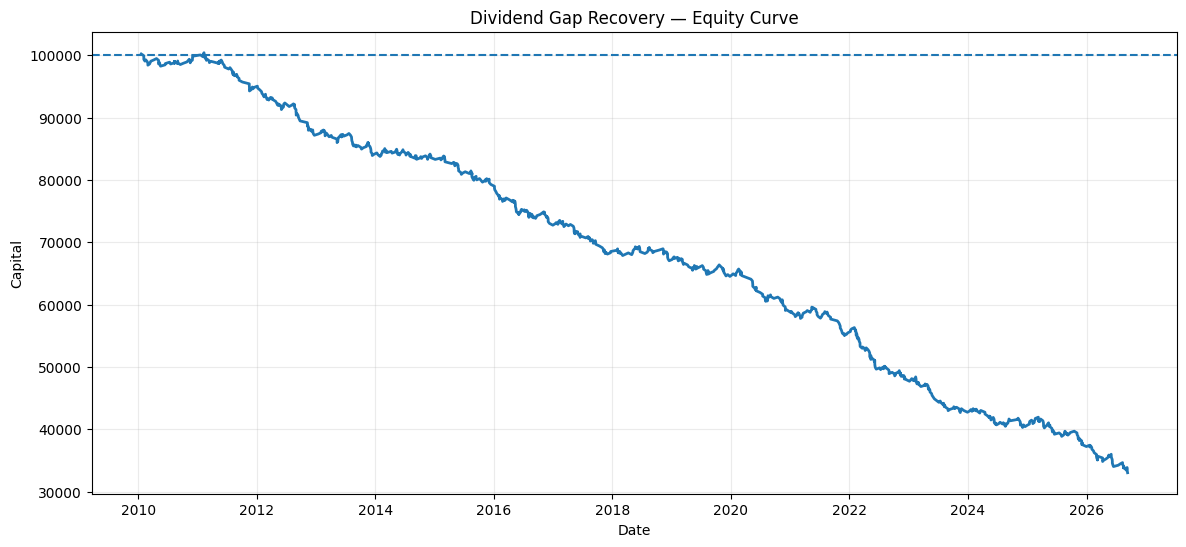

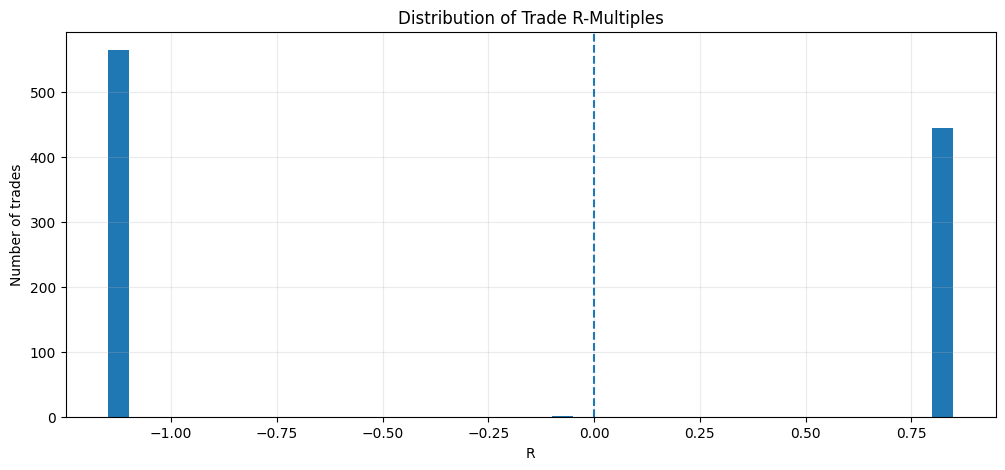

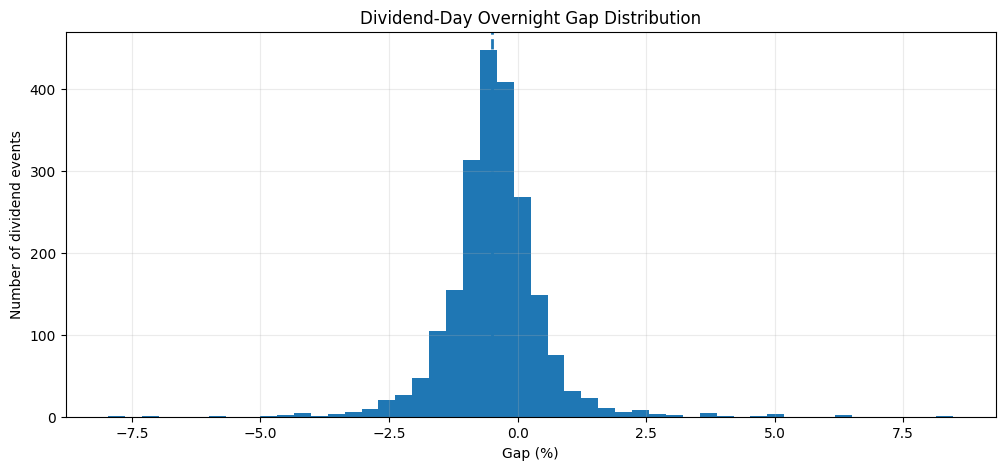



EXIT REASONS
exit_reason
stop_loss                                467
take_profit                              444
stop_and_target_same_bar_conservative     97
time_exit                                  1


MONTE CARLO
Median final capital: $6,300.57
P5 final capital:     $3,703.80
P95 final capital:    $10,696.60
P(max DD >= 10%):     100.00%
P(max DD >= 20%):     100.00%
P(max DD >= 30%):     100.00%


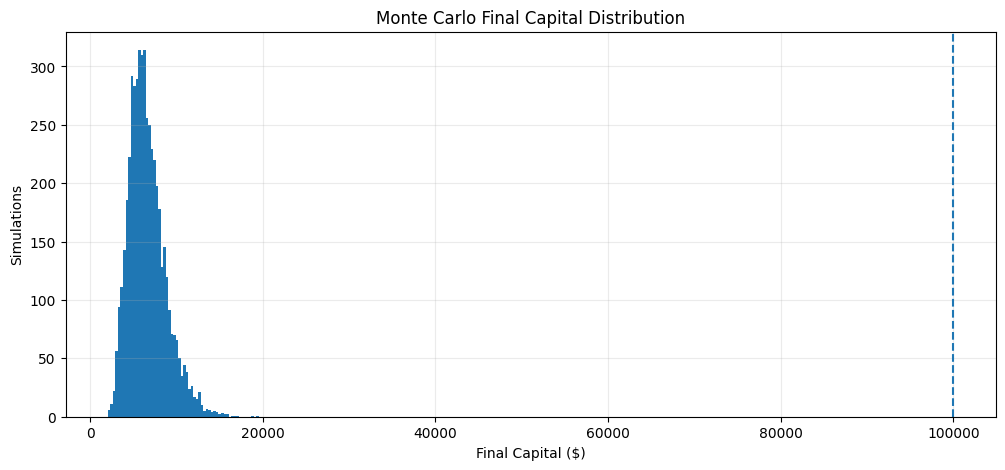



ROBUSTNESS CHECK
Observed average R: -0.2687
Bootstrap 5%: -0.3182
Bootstrap median: -0.2696
Bootstrap 95%: -0.2172
P(avg R <= 0): 100.00%


BEST 10 TRADES
ticker    ex_date entry_date  exit_date       gap        R        pnl exit_reason
   PEP 2012-12-05 2012-12-06 2012-12-11 -0.005153 0.849025 209.225310 take_profit
   MRK 2021-03-12 2021-03-15 2021-03-15 -0.008040 0.849025 208.531427 take_profit
   CVX 2018-05-17 2018-05-18 2018-05-22 -0.006175 0.849025 207.209180 take_profit
  SBUX 2020-08-06 2020-08-07 2020-08-10 -0.007654 0.849025 207.553636 take_profit
  ORCL 2015-07-06 2015-07-07 2015-07-09 -0.010654 0.849025 212.675264 take_profit
     C 2011-05-25 2011-05-26 2011-05-26 -0.006418 0.849025 212.256313 take_profit
   WFC 2013-01-30 2013-01-31 2013-02-01 -0.007939 0.849025 212.064367 take_profit
  ORCL 2025-01-10 2025-01-13 2025-01-14 -0.024151 0.849025 212.612126 take_profit
   XOM 2015-08-11 2015-08-12 2015-08-12 -0.022095 0.849025 209.638278 take_profit
   NKE 2026-09-01 2026

In [3]:
# ================================================================
# REAL DATA DIVIDEND GAP RECOVERY — ROBUST VERSION
# ONE CELL — GOOGLE COLAB / JUPYTER
# ================================================================

!pip -q install yfinance --upgrade

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import time
from datetime import datetime

# ================================================================
# 0. CONFIG
# ================================================================

TICKERS = [
    "AAPL","MSFT","GOOGL","GOOG","AMZN","META","NVDA","TSLA",
    "AVGO","ORCL","ADBE","CRM","AMD","INTC",
    "JPM","BAC","GS","MS","C","WFC","BLK","V","MA",
    "KO","PEP","COST","WMT","MCD","NKE","SBUX",
    "JNJ","PFE","ABBV","MRK","LLY",
    "CAT","GE","HON","XOM","CVX"
]

START = "2010-01-01"
END = None

INITIAL_CAPITAL = 100_000

# ------------------------------------------------
# Strategy parameters
# ------------------------------------------------

# Ex-dividend day must produce a sufficiently negative gap
GAP_THRESHOLD = -0.005       # -0.5%

# Take profit relative to entry
RECOVERY_TARGET = 0.010      # +1.0%

# Stop relative to entry
STOP_PCT = 0.010             # -1.0%

# Maximum holding period
MAX_HOLD_DAYS = 10

# Position sizing
RISK_PER_TRADE = 0.01        # 1% of current capital
MAX_POSITION_PCT = 0.25      # max 25% capital in one position

# Trading costs
COMMISSION = 0.0005          # 5 bps
SLIPPAGE = 0.0005            # 5 bps

# Out-of-sample split
OOS_DATE = "2022-01-01"

# Minimum number of trades required for meaningful statistics
MIN_TRADES_GLOBAL = 50
MIN_TRADES_STOCK = 10

# Random seed
SEED = 42
np.random.seed(SEED)

print("=" * 80)
print("REAL DATA DIVIDEND GAP RECOVERY")
print("=" * 80)
print(f"Period:       {START} -> {END or 'today'}")
print(f"Stocks:       {len(TICKERS)}")
print(f"OOS date:     {OOS_DATE}")
print(f"Initial cap:  ${INITIAL_CAPITAL:,.0f}")
print("=" * 80)


# ================================================================
# 1. ROBUST DATA LOADER
# ================================================================

def normalize_columns(df):
    """
    Makes yfinance columns predictable.
    Handles both normal and MultiIndex DataFrames.
    """

    if df is None or len(df) == 0:
        return pd.DataFrame()

    df = df.copy()

    # Flatten MultiIndex
    if isinstance(df.columns, pd.MultiIndex):
        # If second level contains ticker, take first level
        if len(df.columns.levels) >= 2:
            try:
                df.columns = [
                    str(c[0]).lower()
                    for c in df.columns
                ]
            except:
                df.columns = [
                    str(c[-1]).lower()
                    for c in df.columns
                ]

    df.columns = [str(c).lower() for c in df.columns]

    # Remove duplicate columns
    df = df.loc[:, ~df.columns.duplicated()]

    return df


def download_price_data(ticker, start=START, end=END):
    """
    Download OHLC + actions directly from Yahoo.

    Several fallbacks are used because Yahoo/yfinance
    occasionally behaves differently between versions.
    """

    last_error = None

    # ------------------------------------------------------------
    # METHOD 1: Ticker.history(actions=True)
    # ------------------------------------------------------------

    try:
        tk = yf.Ticker(ticker)

        df = tk.history(
            start=start,
            end=end,
            auto_adjust=False,
            actions=True,
            repair=True
        )

        if df is not None and len(df) > 0:

            df = normalize_columns(df)

            # Rename possible columns
            rename = {}

            for c in df.columns:
                if c == "adj close":
                    rename[c] = "adj_close"

            df = df.rename(columns=rename)

            required = {"open", "high", "low", "close"}

            if required.issubset(df.columns):

                if "dividends" not in df.columns:
                    df["dividends"] = 0.0

                if "stock splits" not in df.columns:
                    df["stock splits"] = 0.0

                df.index = pd.to_datetime(df.index)

                # Remove timezone
                try:
                    df.index = df.index.tz_localize(None)
                except:
                    pass

                return df

    except Exception as e:
        last_error = e


    # ------------------------------------------------------------
    # METHOD 2: Ticker.get_actions()
    # ------------------------------------------------------------

    try:
        tk = yf.Ticker(ticker)

        df = tk.history(
            start=start,
            end=end,
            auto_adjust=False,
            repair=True
        )

        df = normalize_columns(df)

        if len(df) > 0:

            try:
                actions = tk.get_actions()
            except:
                actions = pd.DataFrame()

            if actions is not None and len(actions) > 0:

                actions = actions.copy()
                actions.index = pd.to_datetime(actions.index)

                try:
                    actions.index = actions.index.tz_localize(None)
                except:
                    pass

                if "Dividends" in actions.columns:
                    div_series = actions["Dividends"]
                elif "dividends" in actions.columns:
                    div_series = actions["dividends"]
                else:
                    div_series = pd.Series(
                        0.0,
                        index=actions.index
                    )

                df["dividends"] = div_series.reindex(
                    df.index
                ).fillna(0.0)

            else:
                df["dividends"] = 0.0

            return df

    except Exception as e:
        last_error = e


    # ------------------------------------------------------------
    # METHOD 3: yf.download()
    # ------------------------------------------------------------

    try:

        df = yf.download(
            ticker,
            start=start,
            end=end,
            auto_adjust=False,
            actions=True,
            progress=False,
            threads=False
        )

        df = normalize_columns(df)

        if len(df) > 0:

            if "dividends" not in df.columns:
                df["dividends"] = 0.0

            df.index = pd.to_datetime(df.index)

            try:
                df.index = df.index.tz_localize(None)
            except:
                pass

            return df

    except Exception as e:
        last_error = e


    return pd.DataFrame()


# ================================================================
# 2. LOAD ALL STOCKS
# ================================================================

DATA = {}
FAILED = []

print("\n")
print("=" * 80)
print("DOWNLOADING REAL MARKET DATA")
print("=" * 80)

for i, ticker in enumerate(TICKERS, 1):

    print(
        f"[{i:02d}/{len(TICKERS)}] "
        f"{ticker:<6}",
        end=" "
    )

    df = download_price_data(ticker)

    if df.empty:
        print("FAILED")
        FAILED.append(ticker)
        continue

    # Clean numeric columns
    for col in ["open", "high", "low", "close", "volume", "dividends"]:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    df = df.dropna(
        subset=["open", "high", "low", "close"]
    )

    DATA[ticker] = df

    div_count = int(
        (df["dividends"] > 0).sum()
    )

    print(
        f"{df.index.min().date()} -> "
        f"{df.index.max().date()} | "
        f"{len(df):,} bars | "
        f"{div_count} dividends"
    )

    time.sleep(0.05)


print("\n")
print("=" * 80)
print("DATA SUMMARY")
print("=" * 80)

print(f"Loaded successfully: {len(DATA)} / {len(TICKERS)}")

if FAILED:
    print("Failed:", FAILED)


# ================================================================
# 3. DIVIDEND DIAGNOSTICS
# ================================================================

print("\n")
print("=" * 80)
print("DIVIDEND DATA CHECK")
print("=" * 80)

dividend_summary = []

for ticker, df in DATA.items():

    divs = df[
        df["dividends"] > 0
    ]["dividends"]

    dividend_summary.append({
        "ticker": ticker,
        "bars": len(df),
        "dividend_events": len(divs),
        "total_dividend": divs.sum()
    })

dividend_summary = pd.DataFrame(
    dividend_summary
)

print(
    dividend_summary
    .sort_values("dividend_events", ascending=False)
    .to_string(index=False)
)

total_dividend_events = int(
    dividend_summary["dividend_events"].sum()
)

print(
    f"\nTOTAL DIVIDEND EVENTS: "
    f"{total_dividend_events:,}"
)

if total_dividend_events == 0:

    print("\n")
    print("!!! CRITICAL WARNING !!!")
    print(
        "Yahoo returned ZERO dividend events."
    )
    print(
        "The strategy cannot be tested honestly without"
        " dividend dates."
    )
    print(
        "Inspecting the first ticker:"
    )

    if len(DATA) > 0:
        sample_ticker = list(DATA.keys())[0]
        print(
            DATA[sample_ticker]
            .tail(10)[
                ["open","high","low","close","dividends"]
            ]
        )

    raise RuntimeError(
        "No dividend events were returned by Yahoo. "
        "Do NOT substitute artificial dividend dates."
    )


# ================================================================
# 4. DIVIDEND GAP SIGNAL GENERATION
# ================================================================

def get_dividend_events(df):

    """
    Returns actual Yahoo dividend events.

    The event date is the ex-dividend date represented
    by the dividend action on the trading calendar.
    """

    events = []

    div_rows = df[
        df["dividends"] > 0
    ]

    for date, row in div_rows.iterrows():

        pos = df.index.get_loc(date)

        if isinstance(pos, slice):
            continue

        # Need previous trading day
        if pos <= 0:
            continue

        prev_date = df.index[pos - 1]

        prev_close = float(
            df.loc[prev_date, "close"]
        )

        ex_open = float(
            row["open"]
        )

        if prev_close <= 0:
            continue

        gap = (
            ex_open / prev_close
        ) - 1.0

        events.append({
            "ex_date": date,
            "dividend": float(row["dividends"]),
            "prev_close": prev_close,
            "ex_open": ex_open,
            "gap": gap
        })

    return pd.DataFrame(events)


# ================================================================
# 5. BACKTEST ENGINE
# ================================================================

def backtest_dividend_gap(
    df,
    ticker,
    initial_capital=INITIAL_CAPITAL,
    gap_threshold=GAP_THRESHOLD,
    recovery_target=RECOVERY_TARGET,
    stop_pct=STOP_PCT,
    max_hold_days=MAX_HOLD_DAYS
):

    capital = float(initial_capital)

    events = get_dividend_events(df)

    trades = []

    if events.empty:
        return pd.DataFrame(), capital

    for _, event in events.iterrows():

        ex_date = event["ex_date"]

        # --------------------------------------------------------
        # Signal:
        # dividend event + sufficiently negative overnight gap
        # --------------------------------------------------------

        if event["gap"] > gap_threshold:
            continue

        # --------------------------------------------------------
        # Enter at NEXT trading day's open.
        #
        # This avoids look-ahead:
        # we do not pretend that the ex-date close was known
        # before entering.
        # --------------------------------------------------------

        ex_pos = df.index.get_loc(ex_date)

        if isinstance(ex_pos, slice):
            continue

        entry_pos = ex_pos + 1

        if entry_pos >= len(df):
            continue

        entry_date = df.index[entry_pos]

        entry_open = float(
            df.iloc[entry_pos]["open"]
        )

        if not np.isfinite(entry_open) or entry_open <= 0:
            continue

        # --------------------------------------------------------
        # Entry slippage
        # --------------------------------------------------------

        entry_price = (
            entry_open * (1 + SLIPPAGE)
        )

        # --------------------------------------------------------
        # Risk based position sizing
        # --------------------------------------------------------

        risk_dollar = capital * RISK_PER_TRADE

        risk_per_share = (
            entry_price * stop_pct
        )

        if risk_per_share <= 0:
            continue

        shares_by_risk = (
            risk_dollar / risk_per_share
        )

        max_position_value = (
            capital * MAX_POSITION_PCT
        )

        shares_by_capital = (
            max_position_value / entry_price
        )

        shares = min(
            shares_by_risk,
            shares_by_capital
        )

        if shares <= 0:
            continue

        # --------------------------------------------------------
        # Exit levels
        # --------------------------------------------------------

        stop_price = (
            entry_price * (1 - stop_pct)
        )

        target_price = (
            entry_price * (1 + recovery_target)
        )

        # --------------------------------------------------------
        # Search future bars
        # --------------------------------------------------------

        exit_price = None
        exit_date = None
        exit_reason = None

        last_pos = min(
            entry_pos + max_hold_days,
            len(df) - 1
        )

        for j in range(
            entry_pos,
            last_pos + 1
        ):

            day = df.iloc[j]

            day_date = df.index[j]

            high = float(day["high"])
            low = float(day["low"])
            close = float(day["close"])

            # ----------------------------------------------------
            # IMPORTANT:
            #
            # Daily OHLC cannot tell us whether target or stop
            # was hit first if BOTH occurred on the same day.
            #
            # Conservative assumption:
            # STOP FIRST.
            # ----------------------------------------------------

            if low <= stop_price and high >= target_price:

                exit_price = (
                    stop_price * (1 - SLIPPAGE)
                )

                exit_date = day_date
                exit_reason = "stop_and_target_same_bar_conservative"

                break

            if low <= stop_price:

                exit_price = (
                    stop_price * (1 - SLIPPAGE)
                )

                exit_date = day_date
                exit_reason = "stop_loss"

                break

            if high >= target_price:

                exit_price = (
                    target_price * (1 - SLIPPAGE)
                )

                exit_date = day_date
                exit_reason = "take_profit"

                break

            # ----------------------------------------------------
            # Maximum holding period
            # ----------------------------------------------------

            if j == last_pos:

                exit_price = (
                    close * (1 - SLIPPAGE)
                )

                exit_date = day_date
                exit_reason = "time_exit"

                break

        if exit_price is None:
            continue

        # --------------------------------------------------------
        # P&L
        # --------------------------------------------------------

        gross_pnl = (
            exit_price - entry_price
        ) * shares

        entry_notional = (
            entry_price * shares
        )

        exit_notional = (
            exit_price * shares
        )

        commission_cost = (
            entry_notional * COMMISSION
            +
            exit_notional * COMMISSION
        )

        pnl = (
            gross_pnl - commission_cost
        )

        initial_risk = (
            risk_per_share * shares
        )

        r_multiple = (
            pnl / initial_risk
            if initial_risk > 0
            else np.nan
        )

        capital_before = capital

        capital += pnl

        trades.append({
            "ticker": ticker,
            "ex_date": ex_date,
            "entry_date": entry_date,
            "exit_date": exit_date,
            "dividend": event["dividend"],
            "gap": event["gap"],
            "entry_price": entry_price,
            "exit_price": exit_price,
            "shares": shares,
            "gross_pnl": gross_pnl,
            "commission": commission_cost,
            "pnl": pnl,
            "R": r_multiple,
            "capital_before": capital_before,
            "capital_after": capital,
            "exit_reason": exit_reason
        })

    return pd.DataFrame(trades), capital


# ================================================================
# 6. RUN ALL STOCKS
# ================================================================

print("\n")
print("=" * 80)
print("RUNNING DIVIDEND GAP RECOVERY")
print("=" * 80)

ALL_TRADES = []

stock_reports = []

for ticker, df in DATA.items():

    trades, final_capital = backtest_dividend_gap(
        df=df,
        ticker=ticker
    )

    if len(trades) > 0:
        ALL_TRADES.append(trades)

    stock_reports.append({
        "ticker": ticker,
        "bars": len(df),
        "dividends": int(
            (df["dividends"] > 0).sum()
        ),
        "signals": len(trades),
        "final_capital": final_capital
    })

    print(
        f"{ticker:<6} "
        f"dividends="
        f"{int((df['dividends'] > 0).sum()):3d} "
        f"trades="
        f"{len(trades):3d}"
    )


stock_reports = pd.DataFrame(
    stock_reports
)

if len(ALL_TRADES) == 0:

    print("\n")
    print("=" * 80)
    print("NO QUALIFYING TRADES")
    print("=" * 80)

    print(
        "\nDividend events exist, but none satisfied "
        f"the gap threshold of {GAP_THRESHOLD:.2%}."
    )

    # Diagnostic: distribution of dividend-day gaps
    all_gaps = []

    for ticker, df in DATA.items():

        events = get_dividend_events(df)

        if len(events):
            tmp = events.copy()
            tmp["ticker"] = ticker
            all_gaps.append(tmp)

    if all_gaps:

        gap_df = pd.concat(
            all_gaps,
            ignore_index=True
        )

        print("\nGap distribution:")

        print(
            gap_df["gap"]
            .describe(
                percentiles=[
                    .01,.05,.10,.25,.50,.75,.90,.95,.99
                ]
            )
        )

        print("\nMost negative dividend gaps:")

        print(
            gap_df
            .sort_values("gap")
            .head(20)
            [
                [
                    "ticker",
                    "ex_date",
                    "dividend",
                    "gap"
                ]
            ]
            .to_string(index=False)
        )

    print(
        "\nIf almost no gaps reach -0.5%, "
        "the correct action is to change the hypothesis, "
        "not artificially create trades."
    )

    raise RuntimeError(
        "No strategy trades generated. "
        "See gap diagnostics above."
    )


TRADES = pd.concat(
    ALL_TRADES,
    ignore_index=True
)

TRADES = TRADES.sort_values(
    "exit_date"
).reset_index(drop=True)


# ================================================================
# 7. GLOBAL METRICS
# ================================================================

def calculate_metrics(
    trades,
    initial_capital=INITIAL_CAPITAL
):

    if trades is None or len(trades) == 0:

        return {
            "trades": 0,
            "win_rate": np.nan,
            "avg_R": np.nan,
            "profit_factor": np.nan,
            "total_return_pct": np.nan,
            "max_drawdown_pct": np.nan,
            "final_capital": initial_capital
        }

    pnl = trades["pnl"].astype(float)

    equity = (
        initial_capital
        + pnl.cumsum()
    )

    running_max = equity.cummax()

    drawdown = (
        equity / running_max - 1
    )

    wins = pnl[pnl > 0]
    losses = pnl[pnl < 0]

    gross_profit = (
        wins.sum()
    )

    gross_loss = abs(
        losses.sum()
    )

    if gross_loss > 0:
        profit_factor = (
            gross_profit / gross_loss
        )
    else:
        profit_factor = np.inf

    return {
        "trades": int(len(trades)),
        "win_rate": float(
            (pnl > 0).mean()
        ),
        "avg_R": float(
            trades["R"].mean()
        ),
        "median_R": float(
            trades["R"].median()
        ),
        "profit_factor": float(
            profit_factor
        ),
        "total_return_pct": float(
            (equity.iloc[-1] /
             initial_capital - 1) * 100
        ),
        "max_drawdown_pct": float(
            drawdown.min() * 100
        ),
        "avg_pnl": float(
            pnl.mean()
        ),
        "final_capital": float(
            equity.iloc[-1]
        )
    }


metrics = calculate_metrics(
    TRADES
)


print("\n")
print("=" * 80)
print("GLOBAL RESULTS")
print("=" * 80)

for k, v in metrics.items():

    if isinstance(v, float):

        if "pct" in k:
            print(
                f"{k:25s}: {v:.2f}%"
            )

        elif "capital" in k:
            print(
                f"{k:25s}: ${v:,.2f}"
            )

        elif "win_rate" in k:
            print(
                f"{k:25s}: {v:.2%}"
            )

        else:
            print(
                f"{k:25s}: {v:.4f}"
            )

    else:
        print(
            f"{k:25s}: {v}"
        )


# ================================================================
# 8. BY STOCK
# ================================================================

print("\n")
print("=" * 80)
print("RESULTS BY STOCK")
print("=" * 80)

by_stock = []

for ticker, g in TRADES.groupby("ticker"):

    m = calculate_metrics(g)

    by_stock.append({
        "ticker": ticker,
        "trades": m["trades"],
        "win_rate": m["win_rate"],
        "avg_R": m["avg_R"],
        "profit_factor": m["profit_factor"],
        "return_pct": m["total_return_pct"],
        "max_dd_pct": m["max_drawdown_pct"],
        "avg_pnl": m["avg_pnl"]
    })

by_stock = pd.DataFrame(
    by_stock
).sort_values(
    "avg_R",
    ascending=False
)

print(
    by_stock.to_string(index=False)
)


# ================================================================
# 9. YEARLY RESULTS
# ================================================================

TRADES["year"] = (
    pd.to_datetime(
        TRADES["exit_date"]
    ).dt.year
)

print("\n")
print("=" * 80)
print("YEARLY RESULTS")
print("=" * 80)

by_year = []

for year, g in TRADES.groupby("year"):

    m = calculate_metrics(g)

    by_year.append({
        "year": year,
        "trades": m["trades"],
        "win_rate": m["win_rate"],
        "avg_R": m["avg_R"],
        "profit_factor": m["profit_factor"],
        "return_pct": m["total_return_pct"],
        "max_dd_pct": m["max_drawdown_pct"]
    })

by_year = pd.DataFrame(
    by_year
)

print(
    by_year.to_string(index=False)
)


# ================================================================
# 10. IN-SAMPLE / OUT-OF-SAMPLE
# ================================================================

TRADES["exit_date"] = pd.to_datetime(
    TRADES["exit_date"]
)

IS_TRADES = TRADES[
    TRADES["exit_date"] < OOS_DATE
].copy()

OOS_TRADES = TRADES[
    TRADES["exit_date"] >= OOS_DATE
].copy()


print("\n")
print("=" * 80)
print("IN-SAMPLE VS OUT-OF-SAMPLE")
print("=" * 80)

is_metrics = calculate_metrics(
    IS_TRADES
)

oos_metrics = calculate_metrics(
    OOS_TRADES
)

comparison = pd.DataFrame([
    {
        "period": "IN_SAMPLE",
        **is_metrics
    },
    {
        "period": "OUT_OF_SAMPLE",
        **oos_metrics
    }
])

print(
    comparison.to_string(index=False)
)


# ================================================================
# 11. EQUITY CURVE
# ================================================================

equity = (
    INITIAL_CAPITAL
    + TRADES["pnl"].cumsum()
)

plt.figure(
    figsize=(14, 6)
)

plt.plot(
    TRADES["exit_date"],
    equity,
    linewidth=2
)

plt.axhline(
    INITIAL_CAPITAL,
    linestyle="--"
)

plt.title(
    "Dividend Gap Recovery — Equity Curve"
)

plt.xlabel("Date")
plt.ylabel("Capital")

plt.grid(
    alpha=0.25
)

plt.show()


# ================================================================
# 12. R-MULTIPLE DISTRIBUTION
# ================================================================

plt.figure(
    figsize=(12, 5)
)

plt.hist(
    TRADES["R"],
    bins=40
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Distribution of Trade R-Multiples"
)

plt.xlabel("R")
plt.ylabel("Number of trades")

plt.grid(
    alpha=0.25
)

plt.show()


# ================================================================
# 13. GAP DISTRIBUTION
# ================================================================

all_gap_events = []

for ticker, df in DATA.items():

    events = get_dividend_events(df)

    if len(events):

        events = events.copy()
        events["ticker"] = ticker

        all_gap_events.append(events)


if all_gap_events:

    GAP_EVENTS = pd.concat(
        all_gap_events,
        ignore_index=True
    )

    plt.figure(
        figsize=(12, 5)
    )

    plt.hist(
        GAP_EVENTS["gap"] * 100,
        bins=50
    )

    plt.axvline(
        GAP_THRESHOLD * 100,
        linestyle="--",
        linewidth=2
    )

    plt.title(
        "Dividend-Day Overnight Gap Distribution"
    )

    plt.xlabel(
        "Gap (%)"
    )

    plt.ylabel(
        "Number of dividend events"
    )

    plt.grid(
        alpha=0.25
    )

    plt.show()


# ================================================================
# 14. EXIT REASONS
# ================================================================

print("\n")
print("=" * 80)
print("EXIT REASONS")
print("=" * 80)

print(
    TRADES["exit_reason"]
    .value_counts()
    .to_string()
)


# ================================================================
# 15. MONTE CARLO
# ================================================================

def monte_carlo(
    trades,
    simulations=5000,
    initial_capital=INITIAL_CAPITAL
):

    if len(trades) == 0:
        return None

    R = (
        trades["R"]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
        .values
    )

    if len(R) < 5:
        return None

    results = []

    for _ in range(simulations):

        sampled = np.random.choice(
            R,
            size=len(R),
            replace=True
        )

        capital = initial_capital
        peak = capital
        max_dd = 0

        for r in sampled:

            # R is already relative to the
            # original 1% risk per trade.
            pnl = (
                capital
                * RISK_PER_TRADE
                * r
            )

            capital += pnl

            peak = max(
                peak,
                capital
            )

            dd = (
                capital / peak - 1
            )

            max_dd = min(
                max_dd,
                dd
            )

            if capital <= 0:
                capital = 0
                break

        results.append({
            "final_capital": capital,
            "max_dd": max_dd
        })

    return pd.DataFrame(results)


MC = monte_carlo(
    TRADES,
    simulations=5000
)

print("\n")
print("=" * 80)
print("MONTE CARLO")
print("=" * 80)

if MC is not None:

    print(
        f"Median final capital: "
        f"${MC['final_capital'].median():,.2f}"
    )

    print(
        f"P5 final capital:     "
        f"${MC['final_capital'].quantile(.05):,.2f}"
    )

    print(
        f"P95 final capital:    "
        f"${MC['final_capital'].quantile(.95):,.2f}"
    )

    print(
        f"P(max DD >= 10%):     "
        f"{(MC['max_dd'] <= -0.10).mean():.2%}"
    )

    print(
        f"P(max DD >= 20%):     "
        f"{(MC['max_dd'] <= -0.20).mean():.2%}"
    )

    print(
        f"P(max DD >= 30%):     "
        f"{(MC['max_dd'] <= -0.30).mean():.2%}"
    )

    plt.figure(
        figsize=(12, 5)
    )

    plt.hist(
        MC["final_capital"],
        bins=60
    )

    plt.axvline(
        INITIAL_CAPITAL,
        linestyle="--"
    )

    plt.title(
        "Monte Carlo Final Capital Distribution"
    )

    plt.xlabel(
        "Final Capital ($)"
    )

    plt.ylabel(
        "Simulations"
    )

    plt.grid(
        alpha=0.25
    )

    plt.show()


# ================================================================
# 16. RANDOMIZED DATE / STOCK ROBUSTNESS
# ================================================================

print("\n")
print("=" * 80)
print("ROBUSTNESS CHECK")
print("=" * 80)

# ------------------------------------------------
# Bootstrap trade-level statistics
# ------------------------------------------------

R = (
    TRADES["R"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
    .values
)

bootstrap_avg_R = []

if len(R) >= 10:

    for _ in range(3000):

        sample = np.random.choice(
            R,
            size=len(R),
            replace=True
        )

        bootstrap_avg_R.append(
            np.mean(sample)
        )

    bootstrap_avg_R = np.array(
        bootstrap_avg_R
    )

    print(
        f"Observed average R: "
        f"{np.mean(R):.4f}"
    )

    print(
        f"Bootstrap 5%: "
        f"{np.quantile(bootstrap_avg_R,.05):.4f}"
    )

    print(
        f"Bootstrap median: "
        f"{np.quantile(bootstrap_avg_R,.50):.4f}"
    )

    print(
        f"Bootstrap 95%: "
        f"{np.quantile(bootstrap_avg_R,.95):.4f}"
    )

    print(
        f"P(avg R <= 0): "
        f"{(bootstrap_avg_R <= 0).mean():.2%}"
    )


# ================================================================
# 17. TOP / WORST TRADES
# ================================================================

print("\n")
print("=" * 80)
print("BEST 10 TRADES")
print("=" * 80)

print(
    TRADES[
        [
            "ticker",
            "ex_date",
            "entry_date",
            "exit_date",
            "gap",
            "R",
            "pnl",
            "exit_reason"
        ]
    ]
    .sort_values("R", ascending=False)
    .head(10)
    .to_string(index=False)
)


print("\n")
print("=" * 80)
print("WORST 10 TRADES")
print("=" * 80)

print(
    TRADES[
        [
            "ticker",
            "ex_date",
            "entry_date",
            "exit_date",
            "gap",
            "R",
            "pnl",
            "exit_reason"
        ]
    ]
    .sort_values("R")
    .head(10)
    .to_string(index=False)
)


# ================================================================
# 18. FINAL VERDICT
# ================================================================

print("\n")
print("=" * 80)
print("FINAL VERDICT")
print("=" * 80)

n = metrics["trades"]
avg_r = metrics["avg_R"]
pf = metrics["profit_factor"]
ret = metrics["total_return_pct"]
dd = metrics["max_drawdown_pct"]

print(
    f"""
Trades:              {n}
Win rate:            {metrics['win_rate']:.2%}
Average R:           {avg_r:.4f}
Profit factor:       {pf:.3f}
Total return:        {ret:.2f}%
Maximum drawdown:    {dd:.2f}%
Final capital:       ${metrics['final_capital']:,.2f}

OOS trades:          {oos_metrics['trades']}
OOS win rate:        {oos_metrics['win_rate']:.2%}
OOS average R:       {oos_metrics['avg_R']:.4f}
OOS profit factor:   {oos_metrics['profit_factor']:.3f}
OOS return:          {oos_metrics['total_return_pct']:.2f}%
"""
)

print("-" * 80)

# ------------------------------------------------
# Automatic interpretation
# ------------------------------------------------

if n < MIN_TRADES_GLOBAL:

    print(
        "STATUS: INSUFFICIENT SAMPLE"
    )

    print(
        f"Need at least ~{MIN_TRADES_GLOBAL} trades "
        "before treating the result as meaningful."
    )

elif avg_r <= 0 or pf <= 1:

    print(
        "STATUS: NO ROBUST EDGE DETECTED"
    )

    print(
        "The strategy does not currently show a "
        "positive expectancy after costs."
    )

elif len(OOS_TRADES) < 20:

    print(
        "STATUS: PROMISING BUT INSUFFICIENT OOS"
    )

    print(
        "The aggregate result is positive, but "
        "there are too few OOS trades."
    )

elif (
    oos_metrics["avg_R"] > 0
    and oos_metrics["profit_factor"] > 1
):

    print(
        "STATUS: HYPOTHESIS SURVIVES INITIAL OOS TEST"
    )

    print(
        "This is NOT proof of future profitability."
    )

    print(
        "Next step should be independent validation "
        "and ML filtering, NOT parameter optimization."
    )

else:

    print(
        "STATUS: IN-SAMPLE EDGE DOES NOT SURVIVE OOS"
    )

    print(
        "Likely regime dependence, noise, or overfitting."
    )


# ================================================================
# 19. SAVE RESULTS
# ================================================================

TRADES.to_csv(
    "dividend_gap_all_trades.csv",
    index=False
)

by_stock.to_csv(
    "dividend_gap_by_stock.csv",
    index=False
)

by_year.to_csv(
    "dividend_gap_by_year.csv",
    index=False
)

stock_reports.to_csv(
    "dividend_gap_stock_diagnostics.csv",
    index=False
)

print("\n")
print("=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    "dividend_gap_all_trades.csv"
)

print(
    "dividend_gap_by_stock.csv"
)

print(
    "dividend_gap_by_year.csv"
)

print(
    "dividend_gap_stock_diagnostics.csv"
)

print("\nDONE.")